# Blinkit Data Analytics — Stock and spoilage risk
DuckDB SQL + Python | Yash Prajapati

## 1. Setup

### 1.1 Libraries

In [1]:
import warnings, math, textwrap
warnings.filterwarnings('ignore')
import duckdb, pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', lambda v: f'{v:,.2f}')
plt.rcParams.update({'figure.figsize':(10,4.5),'axes.grid':True,'grid.alpha':.25,'axes.spines.top':False,'axes.spines.right':False,'font.size':10})
print('duckdb', duckdb.__version__, '| pandas', pd.__version__, '| numpy', np.__version__)

duckdb 1.5.5 | pandas 3.0.2 | numpy 2.4.4


### 1.2 Load cleaned workbook

In [2]:
XLSX = 'data/Blinkit_analysis_new.xlsx'
book = pd.read_excel(XLSX, sheet_name=None)
geo = pd.read_csv('data/city_state_zone.csv')
for name, df in book.items():
    print(f'{name:28s} {df.shape[0]:>6,} rows  {df.shape[1]:>3} cols')

Data_Quality_Report              46 rows    3 cols
Orders_Customer_Info          5,000 rows   16 cols
Orders_Raw_Archive            5,000 rows   23 cols
Order_Line_Items              5,000 rows   14 cols
Delivery_Performance          5,000 rows    8 cols
Customer_Feedback             5,000 rows    8 cols
Customers                     2,500 rows   11 cols
Products                        268 rows   10 cols
Inventory_Analysis              268 rows   18 cols
Data_Dictionary                  44 rows    4 cols
Reference_Parameters             11 rows    5 cols
Relational_Diagram                0 rows    0 cols
Pivot_Payment_Method              7 rows    7 cols
Pivot_Customer_Segment            7 rows    5 cols
Pivot_Category_Sales             14 rows    4 cols
Pivot_Monthly_Trend              24 rows    6 cols
Pivot_Area_Delivery              23 rows    6 cols
Pivot_Inventory_Movement          6 rows    7 cols
Pivot_Category_Stock             14 rows    8 cols


### 1.3 Create DuckDB database and load tables

In [3]:
con = duckdb.connect('blinkit.duckdb')
load = {'orders_src':'Orders_Raw_Archive','items_src':'Order_Line_Items','delivery_src':'Delivery_Performance',
        'feedback_src':'Customer_Feedback','customers_src':'Customers','products_src':'Products','inventory_src':'Inventory_Analysis'}
for tbl, sheet in load.items():
    df = book[sheet].copy()
    df.columns = [c.strip() for c in df.columns]
    con.register('tmp_df', df)
    con.execute(f'CREATE OR REPLACE TABLE {tbl} AS SELECT * FROM tmp_df')
con.register('geo_df', geo)
con.execute('CREATE OR REPLACE TABLE geo AS SELECT * FROM geo_df')
con.execute("SELECT table_name, estimated_size FROM duckdb_tables() ORDER BY table_name").df()

,table_name,estimated_size
0,customers_src,2500
1,delivery_src,5000
2,feedback_src,5000
3,geo,316
4,inventory_src,268
5,items_src,5000
6,orders_src,5000
7,products_src,268


### 1.4 Typed analysis views

In [4]:
con.execute('''
CREATE OR REPLACE VIEW orders AS
SELECT order_id, customer_id,
       strptime(order_date, '%d-%m-%Y %H:%M')              AS order_ts,
       CAST(strptime(order_date, '%d-%m-%Y %H:%M') AS DATE) AS order_date,
       strptime(promised_delivery_time, '%d-%m-%Y %H:%M')   AS promised_ts,
       strptime(actual_delivery_time,  '%d-%m-%Y %H:%M')    AS actual_ts,
       delivery_status, order_total, payment_method, delivery_partner_id, store_id,
       CAST(delivery_time_minutes AS INTEGER)               AS delay_min,
       distance_km, reasons_if_delayed, customer_name,
       trim(area) AS area, pincode, customer_segment,
       CAST(registration_date AS DATE)                      AS registration_date,
       order_day_of_week, order_time_slot, order_value_segment,
       CASE WHEN is_weekend = 'Yes' THEN 1 ELSE 0 END       AS is_weekend
FROM orders_src ''')

con.execute('''
CREATE OR REPLACE VIEW items AS
SELECT order_id, product_id, quantity, unit_price, product_name, category, brand,
       price, mrp, margin_percentage, shelf_life_days, min_stock_level, max_stock_level, line_total,
       line_total * margin_percentage / 100.0 AS margin_value
FROM items_src ''')

con.execute('''
CREATE OR REPLACE VIEW feedback AS
SELECT feedback_id, order_id, customer_id, rating, feedback_category, sentiment,
       CAST(feedback_date AS DATE) AS feedback_date
FROM feedback_src ''')

con.execute('''
CREATE OR REPLACE VIEW f_sales AS
SELECT o.order_id, o.customer_id, o.order_ts, o.order_date,
       date_trunc('month', o.order_date)  AS order_month,
       extract(hour FROM o.order_ts)      AS order_hour,
       o.order_day_of_week, o.is_weekend, o.order_time_slot, o.order_value_segment,
       o.payment_method, o.customer_segment, o.registration_date, o.customer_name,
       o.area, g.state, g.zone, g.city_tier,
       i.product_id, i.product_name, i.category, i.brand,
       i.quantity, i.line_total AS revenue, i.margin_value, i.margin_percentage,
       i.price, i.mrp, i.shelf_life_days,
       o.delay_min, o.distance_km, o.delivery_status,
       CASE WHEN o.delivery_status = 'On Time' THEN 1 ELSE 0 END AS is_on_time_status,
       CASE WHEN o.delay_min > 0 THEN 1 ELSE 0 END               AS is_late_minutes,
       f.rating, f.sentiment, f.feedback_category
FROM orders o
JOIN items i    ON i.order_id = o.order_id
LEFT JOIN geo g ON g.area     = o.area
LEFT JOIN feedback f ON f.order_id = o.order_id ''')

con.execute('SELECT COUNT(*) AS fact_rows, COUNT(DISTINCT order_id) AS orders, MIN(order_date) AS first_day, MAX(order_date) AS last_day FROM f_sales').df()

,fact_rows,orders,first_day,last_day
0,5000,5000,2023-03-16,2024-11-04


### 1.5 Query helper

In [5]:
def q(sql, con=con):
    return con.execute(textwrap.dedent(sql)).df()

def pct(x, n):
    return round(100.0 * x / n, 2) if n else 0.0

q('SELECT COUNT(*) AS rows_in_fact_view FROM f_sales')

,rows_in_fact_view
0,5000


### Chart colours

In [6]:
GREEN, GOLD, BLUE, RED, GREY = '#0B7A2A', '#E0A31C', '#2A6FD0', '#CC3B37', '#8A938D'

## 9. Inventory and wastage risk

### 9.1 Stock cover against shelf life

In [7]:
stock = q('''
SELECT p.product_id, p.product_name, p.category, p.price, p.shelf_life_days,
       p.min_stock_level, p.max_stock_level,
       COALESCE(i.units_sold, 0)        AS units_sold,
       COALESCE(i.revenue, 0)           AS revenue,
       round(i.avg_monthly_demand, 2)   AS avg_monthly_demand,
       round(p.shelf_life_days / 30.44, 2) AS shelf_life_months,
       round(i.stock_cover_months_at_min, 2) AS stock_cover_months
FROM products_src p LEFT JOIN inventory_src i ON i.product_id = p.product_id ''')
stock['wastage_risk'] = np.where(stock.stock_cover_months > stock.shelf_life_months, 'At risk', 'Within shelf life')
stock.groupby('wastage_risk').agg(products=('product_id','count'), revenue=('revenue','sum'),
    min_stock_units=('min_stock_level','sum')).assign(
    product_share_pct=lambda d: (100*d.products/d.products.sum()).round(2),
    revenue_share_pct=lambda d: (100*d.revenue/d.revenue.sum()).round(2)).reset_index()

,wastage_risk,products,revenue,min_stock_units,product_share_pct,revenue_share_pct
0,At risk,180,"3,022,373.28",3951,67.16,60.78
1,Within shelf life,88,"1,950,042.15",1513,32.84,39.22


### 9.1b Demand figures cross-checked against the order data

In [8]:
check = q('''
WITH period AS (SELECT COUNT(DISTINCT date_trunc('month', order_date)) AS months FROM f_sales),
sold AS (SELECT product_id, SUM(quantity) AS units_sold FROM f_sales GROUP BY 1)
SELECT i.product_id, i.units_sold AS units_in_inventory_sheet, s.units_sold AS units_in_orders,
       round(i.avg_monthly_demand, 3) AS demand_in_sheet,
       round(s.units_sold * 1.0 / (SELECT months FROM period), 3) AS demand_recomputed
FROM inventory_src i JOIN sold s ON s.product_id = i.product_id ''')
pd.DataFrame([{'products_compared': len(check),
               'units_match': int((check.units_in_inventory_sheet == check.units_in_orders).sum()),
               'max_demand_difference': round((check.demand_in_sheet - check.demand_recomputed).abs().max(), 3),
               'months_used': 21}])

,products_compared,units_match,max_demand_difference,months_used
0,268,268,0.23,21


### 9.2 Risk by category

In [9]:
stock.groupby('category').apply(lambda g: pd.Series({
    'products': len(g),
    'at_risk': int((g.wastage_risk == 'At risk').sum()),
    'at_risk_pct': round(100*(g.wastage_risk == 'At risk').mean(), 1),
    'median_shelf_life_days': g.shelf_life_days.median(),
    'median_cover_months': round(g.stock_cover_months.median(), 2),
    'revenue': round(g.revenue.sum(), 0)}), include_groups=False).sort_values('at_risk_pct', ascending=False).reset_index()

,category,products,at_risk,at_risk_pct,median_shelf_life_days,median_cover_months,revenue
0,Dairy & Breakfast,30.00,30.00,100.00,7.00,10.15,"639,222.00"
1,Snacks & Munchies,27.00,27.00,100.00,90.00,11.20,"394,649.00"
2,Fruits & Vegetables,27.00,27.00,100.00,3.00,11.30,"559,053.00"
3,Cold Drinks & Juices,22.00,20.00,90.90,180.00,12.35,"392,718.00"
4,Instant & Frozen Food,20.00,17.00,85.00,180.00,8.85,"307,213.00"
5,Personal Care,25.00,14.00,56.00,365.00,12.40,"394,895.00"
6,Grocery & Staples,24.00,12.00,50.00,365.00,11.75,"359,938.00"
7,Pet Care,25.00,11.00,44.00,365.00,10.70,"539,889.00"
8,Pharmacy,25.00,9.00,36.00,365.00,10.50,"592,369.00"
9,Household Care,27.00,9.00,33.30,365.00,9.10,"444,244.00"


### 9.3 Shelf life against minimum stock level

In [10]:
sp = stats.spearmanr(stock.shelf_life_days, stock.min_stock_level)
pe = stats.pearsonr(stock.shelf_life_days, stock.min_stock_level)
pd.DataFrame([{'test':'Spearman (shelf life vs min stock)','statistic':round(sp.statistic,4),'p_value':round(sp.pvalue,4)},
              {'test':'Pearson (shelf life vs min stock)','statistic':round(pe[0],4),'p_value':round(pe[1],4)},
              {'test':'Spearman (monthly demand vs min stock)',
               'statistic':round(stats.spearmanr(stock.avg_monthly_demand, stock.min_stock_level).statistic,4),
               'p_value':round(stats.spearmanr(stock.avg_monthly_demand, stock.min_stock_level).pvalue,4)}])

,test,statistic,p_value
0,Spearman (shelf life vs min stock),0.04,0.50
1,Pearson (shelf life vs min stock),0.04,0.49
2,Spearman (monthly demand vs min stock),0.03,0.62


### 9.4 Risk independence across categories

In [11]:
ct = pd.crosstab(stock.category, stock.wastage_risk)
chi2, p, dof, exp = stats.chi2_contingency(ct)
cramers_v = np.sqrt(chi2 / (ct.values.sum() * (min(ct.shape) - 1)))
pd.DataFrame([{'test':'Chi-square: category vs wastage risk','chi2':round(chi2,3),'dof':dof,
               'p_value':round(p,5),'cramers_v':round(cramers_v,3)}])

,test,chi2,dof,p_value,cramers_v
0,Chi-square: category vs wastage risk,98.20,10,0.00,0.60


### 9.5 Wastage exposure in rupees

In [12]:
stock['excess_units'] = (stock.min_stock_level - stock.avg_monthly_demand * stock.shelf_life_months).clip(lower=0)
stock['exposure_value'] = stock.excess_units * stock.price
exposure = stock.sort_values('exposure_value', ascending=False)
exposure['cum_share'] = 100 * exposure.exposure_value.cumsum() / exposure.exposure_value.sum()
pd.DataFrame([{'total_exposure_units': round(stock.excess_units.sum(), 0),
               'total_exposure_value': round(stock.exposure_value.sum(), 0),
               'exposure_at_cost_70pct': round(stock.exposure_value.sum()*0.7, 0),
               'products_with_exposure': int((stock.exposure_value > 0).sum()),
               'products_making_80pct_of_exposure': int((exposure.cum_share <= 80).sum() + 1)}])

,total_exposure_units,total_exposure_value,exposure_at_cost_70pct,products_with_exposure,products_making_80pct_of_exposure
0,"2,198.00","1,112,064.00","778,445.00",180,72


### 9.6 Highest exposure products

In [13]:
exposure.head(12)[['product_id','product_name','category','shelf_life_days','min_stock_level',
                    'avg_monthly_demand','stock_cover_months','excess_units','exposure_value']].round(2)

,product_id,product_name,category,shelf_life_days,min_stock_level,avg_monthly_demand,stock_cover_months,excess_units,exposure_value
55,455083,Butter,Dairy & Breakfast,7,29,1.52,19.10,28.65,"27,476.02"
39,880510,Bread,Dairy & Breakfast,7,29,2.95,9.80,28.32,"26,945.92"
9,34186,Mangoes,Fruits & Vegetables,3,27,3.10,8.70,26.69,"24,705.60"
6,222892,Tomatoes,Fruits & Vegetables,3,28,1.98,14.10,27.80,"24,166.05"
35,714999,Bread,Dairy & Breakfast,7,27,1.37,19.70,26.68,"23,549.69"
15,349294,Onions,Fruits & Vegetables,3,25,2.44,10.20,24.76,"23,140.67"
17,871592,Carrots,Fruits & Vegetables,3,25,1.78,14.00,24.82,"21,602.34"
16,847349,Potatoes,Fruits & Vegetables,3,26,1.68,15.50,25.83,"20,176.86"
8,39154,Mangoes,Fruits & Vegetables,3,21,2.03,10.30,20.80,"19,691.85"
11,478531,Carrots,Fruits & Vegetables,3,24,2.69,8.90,23.73,"19,588.99"


### 9.7 Safety stock and reorder point

In [14]:
LEAD_TIME_MONTHS = 0.25
Z = 1.65
monthly_units = q('SELECT product_id, order_month, SUM(quantity) AS units FROM f_sales GROUP BY 1, 2')
pv = monthly_units.pivot_table(index='product_id', columns='order_month', values='units', aggfunc='sum').fillna(0)
sd = pv.std(axis=1).rename('sd_units')
plan = stock.set_index('product_id').join(sd).fillna({'sd_units': 0})
plan['safety_stock'] = (Z * plan.sd_units * np.sqrt(LEAD_TIME_MONTHS)).round(0)
plan['reorder_point'] = (plan.avg_monthly_demand * LEAD_TIME_MONTHS + plan.safety_stock).round(0)
plan['rec_min_stock'] = np.minimum(plan.min_stock_level,
    np.ceil(plan.avg_monthly_demand * plan.shelf_life_months * 0.8)).clip(lower=1)
plan['cut_units'] = (plan.min_stock_level - plan.rec_min_stock).clip(lower=0)
plan['released_value'] = plan.cut_units * plan.price
plan[['product_name','category','min_stock_level','avg_monthly_demand','safety_stock',
      'reorder_point','rec_min_stock','cut_units']].head(12).round(2)

,product_name,category,min_stock_level,avg_monthly_demand,safety_stock,reorder_point,rec_min_stock,cut_units
product_id,,,,,,,,
153019,Onions,Fruits & Vegetables,13,2.08,2.00,3.00,1.00,12.00
11422,Potatoes,Fruits & Vegetables,20,1.37,1.00,1.00,1.00,19.00
669378,Potatoes,Fruits & Vegetables,23,2.08,2.00,3.00,1.00,22.00
848226,Tomatoes,Fruits & Vegetables,10,1.58,1.00,1.00,1.00,9.00
890623,Onions,Fruits & Vegetables,27,0.66,1.00,1.00,1.00,26.00
965755,Bananas,Fruits & Vegetables,21,1.47,2.00,2.00,1.00,20.00
222892,Tomatoes,Fruits & Vegetables,28,1.98,3.00,3.00,1.00,27.00
516376,Onions,Fruits & Vegetables,21,2.13,2.00,3.00,1.00,20.00
39154,Mangoes,Fruits & Vegetables,21,2.03,2.00,3.00,1.00,20.00


### 9.8 Impact of the recommended stock levels

In [15]:
pd.DataFrame([{'current_min_stock_units': int(plan.min_stock_level.sum()),
               'recommended_min_stock_units': int(plan.rec_min_stock.sum()),
               'units_released': int(plan.cut_units.sum()),
               'reduction_pct': round(100*plan.cut_units.sum()/plan.min_stock_level.sum(), 2),
               'products_reduced': int((plan.cut_units > 0).sum()),
               'value_released': round(plan.released_value.sum(), 0)}])

,current_min_stock_units,recommended_min_stock_units,units_released,reduction_pct,products_reduced,value_released
0,5464,2969,2495,45.66,203,"1,240,232.00"


### 9.9 Movement classes against stock policy

In [16]:
plan['movement'] = pd.cut(plan.units_sold, [-1, 20, 50, np.inf], labels=['Slow','Medium','Fast'])
pd.crosstab(plan.movement, plan.wastage_risk, margins=True, margins_name='Total')

wastage_risk,At risk,Within shelf life,Total
movement,,,
Slow,4,1,5
Medium,169,72,241
Fast,7,15,22
Total,180,88,268


## Charts

### 16.4 Stock cover against shelf life

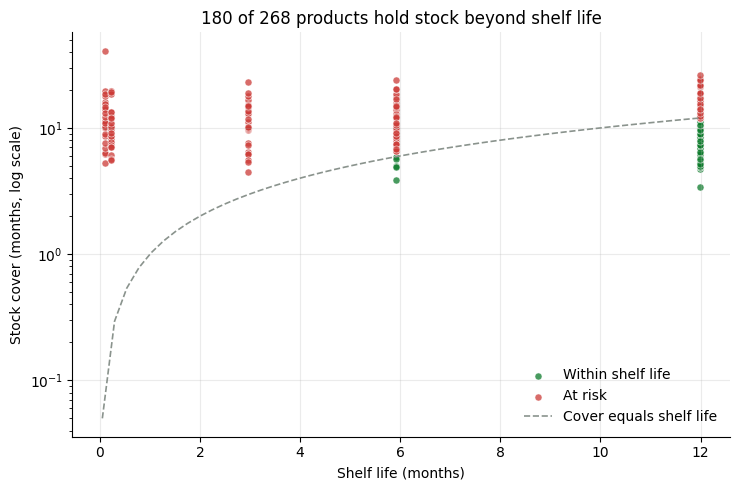

In [17]:
s = stock.dropna(subset=['stock_cover_months'])
fig, ax = plt.subplots(figsize=(7.5, 5))
risky = s[s.wastage_risk == 'At risk']; safe = s[s.wastage_risk != 'At risk']
ax.scatter(safe.shelf_life_months, safe.stock_cover_months, s=26, color=GREEN, alpha=.75, label='Within shelf life', edgecolor='white', lw=.5)
ax.scatter(risky.shelf_life_months, risky.stock_cover_months, s=26, color=RED, alpha=.75, label='At risk', edgecolor='white', lw=.5)
lim = np.linspace(0.05, s.shelf_life_months.max(), 50)
ax.plot(lim, lim, color=GREY, ls='--', lw=1.2, label='Cover equals shelf life')
ax.set_yscale('log'); ax.set_xlabel('Shelf life (months)'); ax.set_ylabel('Stock cover (months, log scale)')
ax.set_title(f'{len(risky)} of {len(s)} products hold stock beyond shelf life'); ax.legend(frameon=False)
plt.tight_layout(); plt.show()